In [1]:
from google.colab import files

uploaded = files.upload()

Saving Scores.csv to Scores.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import probplot

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv(
    "Scores.csv",
    sep=";"
)

df.head()

,Unnamed: 0,student_id,gender,parental.level.of.education,subject,score
0,1,id_001,female,high school,math,23
1,2,id_001,female,high school,language,40
2,3,id_002,female,high school,math,68
3,4,id_002,female,high school,language,"80,5"
4,5,id_003,male,high school,math,82


In [4]:
df['score'] = (
    df['score']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [5]:
print("Shape:", df.shape)

display(df.head())

df.info()

Shape: (972, 6)


,Unnamed: 0,student_id,gender,parental.level.of.education,subject,score
0,1,id_001,female,high school,math,23.0
1,2,id_001,female,high school,language,40.0
2,3,id_002,female,high school,math,68.0
3,4,id_002,female,high school,language,80.5
4,5,id_003,male,high school,math,82.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   972 non-null    int64  
 1   student_id                   972 non-null    object 
 2   gender                       972 non-null    object 
 3   parental.level.of.education  972 non-null    object 
 4   subject                      972 non-null    object 
 5   score                        972 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 45.7+ KB


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
student_id,0
gender,0
parental.level.of.education,0
subject,0
score,0


In [7]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


In [8]:
print(df['gender'].unique())

print(df['subject'].unique())

print(df['parental.level.of.education'].unique())

['female' 'male']
['math' 'language']
['high school' "associate's degree" "bachelor's degree" "master's degree"]


Convert Long Format → Wide Format


In [9]:
wide_df = df.pivot_table(
    index=[
        'student_id',
        'gender',
        'parental.level.of.education'
    ],
    columns='subject',
    values='score'
).reset_index()

wide_df.head()

subject,student_id,gender,parental.level.of.education,language,math
0,id_001,female,high school,40.0,23.0
1,id_002,female,high school,80.5,68.0
2,id_003,male,high school,81.0,82.0
3,id_004,female,high school,60.5,58.0
4,id_005,female,high school,69.0,60.0


In [10]:
wide_df.columns = [
    'student_id',
    'gender',
    'parent_education',
    'language_score',
    'math_score'
]

wide_df.head()

,student_id,gender,parent_education,language_score,math_score
0,id_001,female,high school,40.0,23.0
1,id_002,female,high school,80.5,68.0
2,id_003,male,high school,81.0,82.0
3,id_004,female,high school,60.5,58.0
4,id_005,female,high school,69.0,60.0


Descriptive Statistics

In [11]:
wide_df[
    ['math_score','language_score']
].describe().T

,count,mean,std,min,25%,50%,75%,max
math_score,486.0,66.380658,15.054580,23.0,56.0,66.0,77.75,100.0
language_score,486.0,69.001029,14.446257,19.5,58.0,70.0,78.50,100.0


Advanced Statistics

In [12]:
for col in ['math_score','language_score']:

    print("\n" + "="*50)
    print(col)

    print("Mean:", wide_df[col].mean())
    print("Median:", wide_df[col].median())
    print("Variance:", wide_df[col].var())
    print("Std:", wide_df[col].std())
    print("Min:", wide_df[col].min())
    print("Max:", wide_df[col].max())
    print("Skewness:", wide_df[col].skew())
    print("Kurtosis:", wide_df[col].kurt())


math_score
Mean: 66.38065843621399
Median: 66.0
Variance: 226.64036740061928
Std: 15.054579615539561
Min: 23.0
Max: 100.0
Skewness: -0.06724788522817805
Kurtosis: -0.4194937139475683

language_score
Mean: 69.00102880658436
Median: 70.0
Variance: 208.69432883628195
Std: 14.446256568269925
Min: 19.5
Max: 100.0
Skewness: -0.11087219671339701
Kurtosis: -0.28602536557734615


Gender Distribution

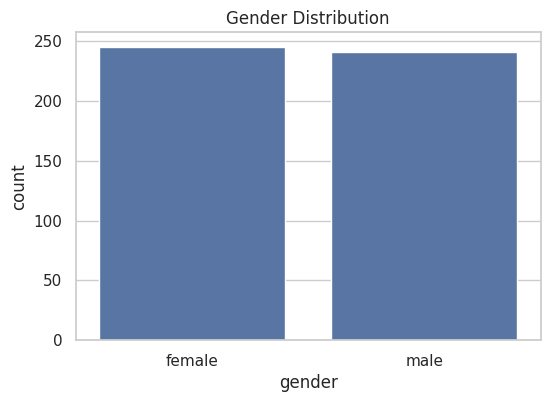

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=wide_df,
    x='gender'
)

plt.title("Gender Distribution")
plt.show()

parent education level


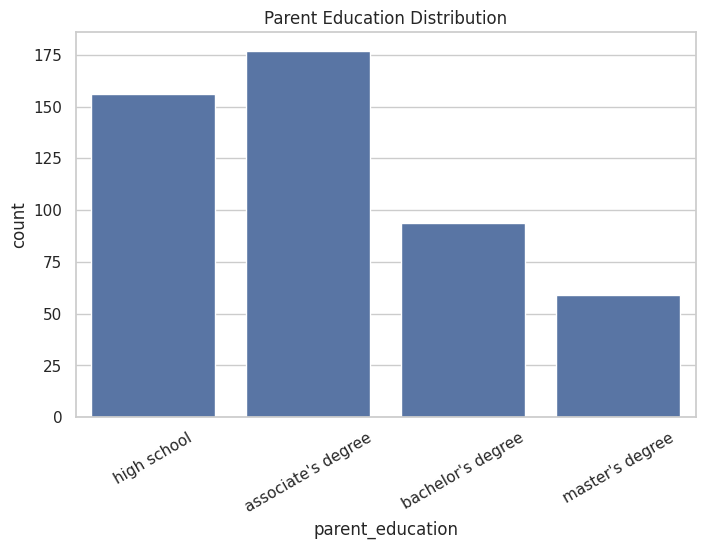

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=wide_df,
    x='parent_education'
)

plt.xticks(rotation=30)

plt.title("Parent Education Distribution")
plt.show()

Mathematics Histogram

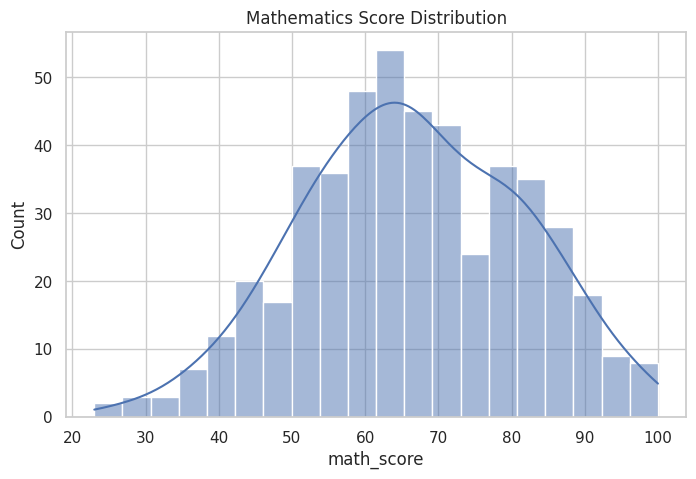

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    wide_df['math_score'],
    bins=20,
    kde=True
)

plt.title("Mathematics Score Distribution")

plt.show()

Language  Histogram

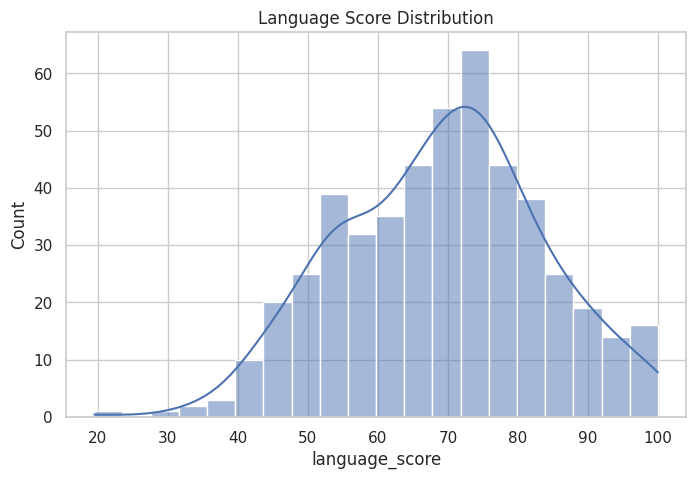

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    wide_df['language_score'],
    bins=20,
    kde=True
)

plt.title("Language Score Distribution")

plt.show()

Boxplot Gender vs Math

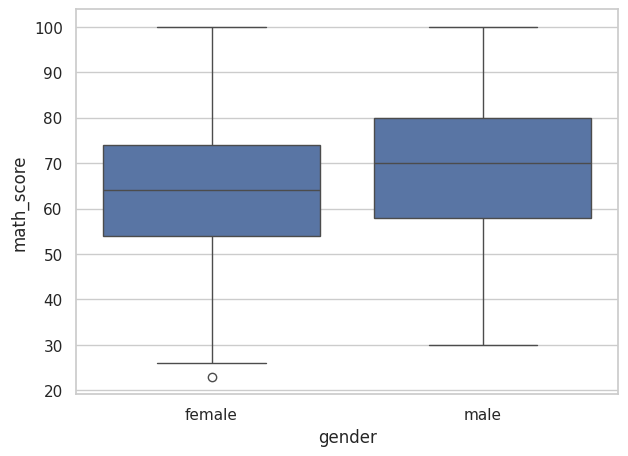

In [17]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=wide_df,
    x='gender',
    y='math_score'
)

plt.show()

Boxplot Gender vs language

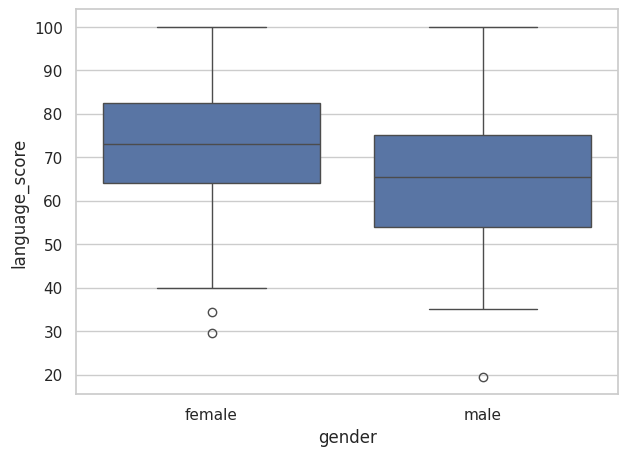

In [18]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=wide_df,
    x='gender',
    y='language_score'
)

plt.show()

Boxplot Parent Education vs Math

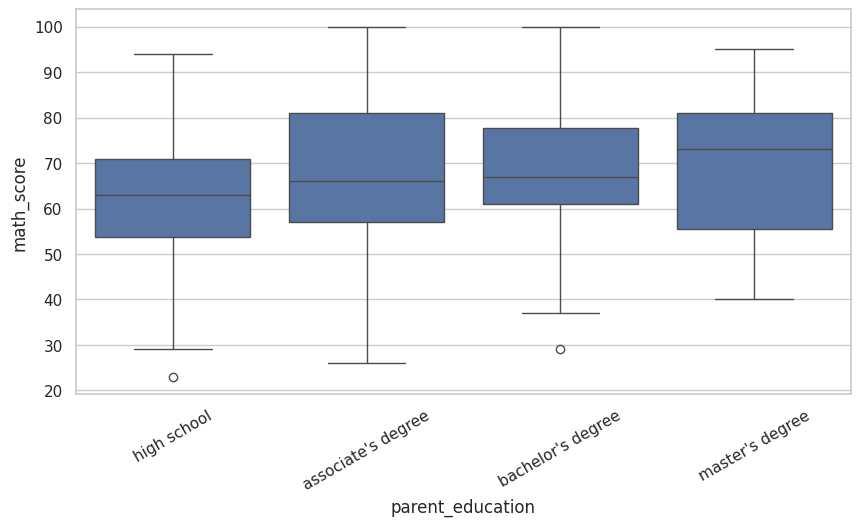

In [19]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=wide_df,
    x='parent_education',
    y='math_score'
)

plt.xticks(rotation=30)

plt.show()

Boxplot Parent Education vs language

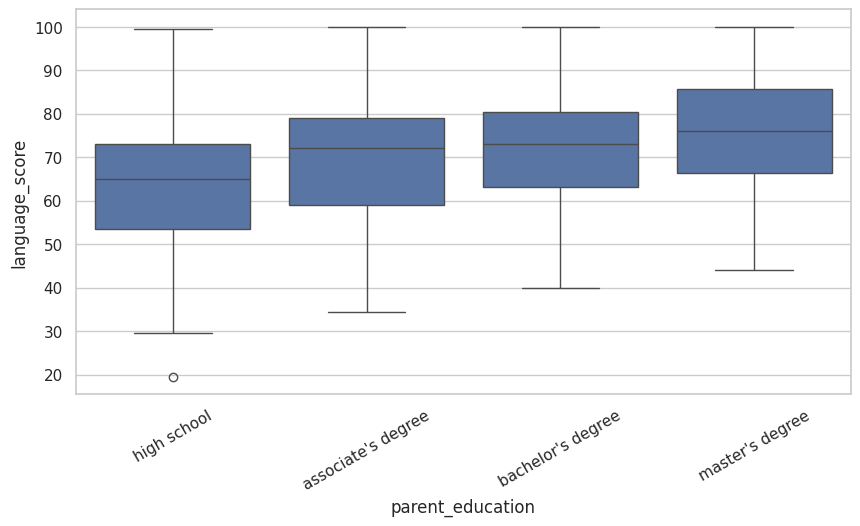

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=wide_df,
    x='parent_education',
    y='language_score'
)

plt.xticks(rotation=30)

plt.show()

Correlation Heatmap

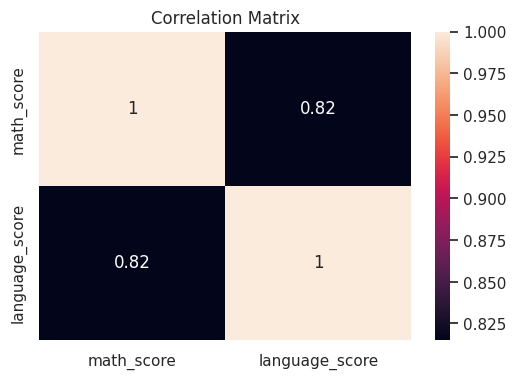

In [24]:
corr = wide_df[
    ['math_score','language_score']
].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

Shapiro-Wilk Normality Test

In [21]:
for col in ['math_score','language_score']:

    stat,p = stats.shapiro(
        wide_df[col]
    )

    print("\n",col)

    print("Statistic =",stat)

    print("P-value =",p)


 math_score
Statistic = 0.9942440444213221
P-value = 0.06363944229013985

 language_score
Statistic = 0.9934917080547938
P-value = 0.03439203174080755


In [22]:
if p > 0.05:
    print("Normal")
else:
    print("Not Normal")

Not Normal


In [38]:
from scipy.stats import shapiro

print("="*60)
print("SHAPIRO-WILK NORMALITY TEST")
print("="*60)

for col in ['math_score', 'language_score']:

    stat, p = shapiro(wide_df[col])

    print(f"\nVariable: {col}")
    print(f"Statistic = {stat:.4f}")
    print(f"P-value = {p:.6f}")

    if p > 0.05:
        print("Decision: Fail to Reject H0")
        print("Conclusion: Data is approximately normal.")
    else:
        print("Decision: Reject H0")
        print("Conclusion: Data is NOT normally distributed.")

SHAPIRO-WILK NORMALITY TEST

Variable: math_score
Statistic = 0.9942
P-value = 0.063639
Decision: Fail to Reject H0
Conclusion: Data is approximately normal.

Variable: language_score
Statistic = 0.9935
P-value = 0.034392
Decision: Reject H0
Conclusion: Data is NOT normally distributed.


Q-Q Plots

maths

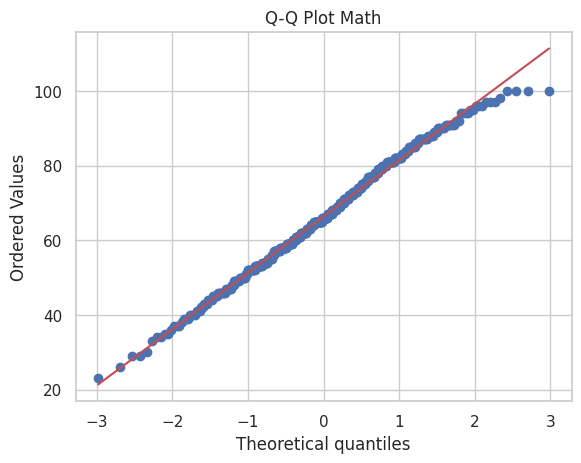

In [25]:
probplot(
    wide_df['math_score'],
    dist='norm',
    plot=plt
)

plt.title("Q-Q Plot Math")

plt.show()

language

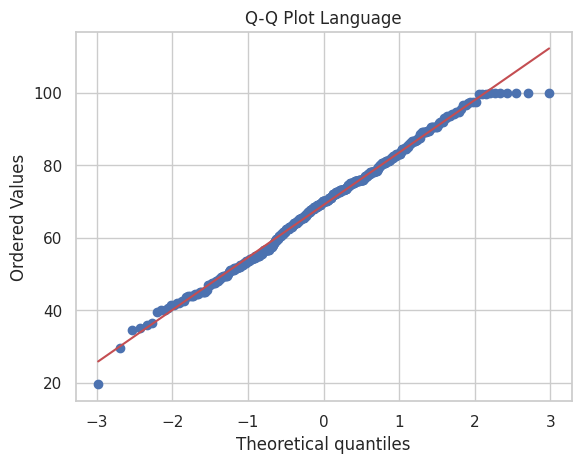

In [26]:
probplot(
    wide_df['language_score'],
    dist='norm',
    plot=plt
)

plt.title("Q-Q Plot Language")

plt.show()

Gender t-Test


In [27]:
male_math = wide_df[
    wide_df['gender']=='male'
]['math_score']

female_math = wide_df[
    wide_df['gender']=='female'
]['math_score']

t_stat,p = stats.ttest_ind(
    male_math,
    female_math
)

print("T Statistic:", t_stat)

print("P-value:", p)

T Statistic: 3.776486726932324
P-value: 0.00017884036695534617


Language t-Test


In [28]:
male_lang = wide_df[
    wide_df['gender']=='male'
]['language_score']

female_lang = wide_df[
    wide_df['gender']=='female'
]['language_score']

t_stat,p = stats.ttest_ind(
    male_lang,
    female_lang
)

print("T Statistic:", t_stat)

print("P-value:", p)

T Statistic: -6.4086525838038595
P-value: 3.4875716929991254e-10


cohen's d

In [29]:
def cohens_d(x,y):

    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        (
            ((nx-1)*x.var()) +
            ((ny-1)*y.var())
        )/(nx+ny-2)
    )

    return (x.mean()-y.mean())/pooled_std

In [30]:
print(
    "Math Cohen's d:",
    cohens_d(male_math,female_math)
)

print(
    "Language Cohen's d:",
    cohens_d(male_lang,female_lang)
)

Math Cohen's d: 0.3426214382291689
Language Cohen's d: -0.5814244625076648


levene Test

In [39]:
from scipy.stats import levene

print("="*60)
print("LEVENE TEST FOR EQUALITY OF VARIANCES")
print("="*60)

# Gender - Math
male_math = wide_df[
    wide_df['gender']=='male'
]['math_score']

female_math = wide_df[
    wide_df['gender']=='female'
]['math_score']

stat,p = levene(
    male_math,
    female_math
)

print("\nMath Score by Gender")
print("Statistic =", round(stat,4))
print("P-value =", round(p,6))

# Gender - Language
male_lang = wide_df[
    wide_df['gender']=='male'
]['language_score']

female_lang = wide_df[
    wide_df['gender']=='female'
]['language_score']

stat,p = levene(
    male_lang,
    female_lang
)

print("\nLanguage Score by Gender")
print("Statistic =", round(stat,4))
print("P-value =", round(p,6))

# Parent Education - Math
groups_math = [
    group['math_score'].values
    for _, group in wide_df.groupby('parent_education')
]

stat,p = levene(*groups_math)

print("\nMath Score by Parent Education")
print("Statistic =", round(stat,4))
print("P-value =", round(p,6))

# Parent Education - Language
groups_lang = [
    group['language_score'].values
    for _, group in wide_df.groupby('parent_education')
]

stat,p = levene(*groups_lang)

print("\nLanguage Score by Parent Education")
print("Statistic =", round(stat,4))
print("P-value =", round(p,6))

LEVENE TEST FOR EQUALITY OF VARIANCES

Math Score by Gender
Statistic = 0.006
P-value = 0.93815

Language Score by Gender
Statistic = 0.1596
P-value = 0.689703

Math Score by Parent Education
Statistic = 1.2748
P-value = 0.282359

Language Score by Parent Education
Statistic = 0.1693
P-value = 0.917083


ANOVA(MATHS)

In [31]:
model = ols(
    'math_score ~ C(parent_education)',
    data=wide_df
).fit()

anova_math = sm.stats.anova_lm(
    model,
    typ=2
)

anova_math

,sum_sq,df,F,PR(>F)
C(parent_education),4098.683680,3.0,6.222926,0.000375
Residual,105821.894509,482.0,NaN,NaN


Tukey HSD- MATHS

In [32]:
tukey_math = pairwise_tukeyhsd(
    endog=wide_df['math_score'],
    groups=wide_df['parent_education'],
    alpha=0.05
)

print(tukey_math)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------


ANOVA(LANGUAGE)

In [33]:
model = ols(
    'language_score ~ C(parent_education)',
    data=wide_df
).fit()

anova_lang = sm.stats.anova_lm(
    model,
    typ=2
)

anova_lang

,sum_sq,df,F,PR(>F)
C(parent_education),8240.860082,3.0,14.24059,6.617864e-09
Residual,92975.889404,482.0,NaN,NaN


Eta Squared for ANOVA

In [40]:
print("="*60)
print("EFFECT SIZE (ETA SQUARED)")
print("="*60)

eta_sq_math = (
    anova_math['sum_sq'][0]
    /
    anova_math['sum_sq'].sum()
)

eta_sq_lang = (
    anova_lang['sum_sq'][0]
    /
    anova_lang['sum_sq'].sum()
)

print("\nMath ANOVA Eta Squared:")
print(round(eta_sq_math,4))

print("\nLanguage ANOVA Eta Squared:")
print(round(eta_sq_lang,4))

EFFECT SIZE (ETA SQUARED)

Math ANOVA Eta Squared:
0.0373

Language ANOVA Eta Squared:
0.0814


Tukkey HSD- LANGUAGE

In [34]:
tukey_lang = pairwise_tukeyhsd(
    endog=wide_df['language_score'],
    groups=wide_df['parent_education'],
    alpha=0.05
)

print(tukey_lang)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   2.0359 0.6596  -2.5337  6.6055  False
associate's degree       high school  -6.4905 0.0001 -10.4226 -2.5585   True
associate's degree   master's degree   5.5028 0.0429   0.1202 10.8854   True
 bachelor's degree       high school  -8.5265    0.0 -13.2016 -3.8514   True
 bachelor's degree   master's degree   3.4669 0.4365  -2.4802   9.414  False
       high school   master's degree  11.9934    0.0    6.521 17.4658   True
----------------------------------------------------------------------------


Gender mean score

In [41]:
gender_means = wide_df.groupby(
    'gender'
)[['math_score','language_score']].mean()

display(gender_means)

,math_score,language_score
gender,,
female,63.857143,73.004082
male,68.946058,64.931535


Final Summary Table


In [37]:
math_t_stat, math_t_p = stats.ttest_ind(male_math, female_math)
lang_t_stat, lang_t_p = stats.ttest_ind(male_lang, female_lang)

math_anova_f = anova_math.loc['C(parent_education)', 'F']
math_anova_p = anova_math.loc['C(parent_education)', 'PR(>F)']

lang_anova_f = anova_lang.loc['C(parent_education)', 'F']
lang_anova_p = anova_lang.loc['C(parent_education)', 'PR(>F)']

summary = pd.DataFrame({
    "Research Question": [
        "Gender vs Math",
        "Gender vs Language",
        "Parent Education vs Math",
        "Parent Education vs Language"
    ],
    "Method": [
        "Independent t-Test",
        "Independent t-Test",
        "One-Way ANOVA",
        "One-Way ANOVA"
    ],
    "Statistic": [
        math_t_stat,
        lang_t_stat,
        math_anova_f,
        lang_anova_f
    ],
    "P-value": [
        math_t_p,
        lang_t_p,
        math_anova_p,
        lang_anova_p
    ]
})

summary

,Research Question,Method,Statistic,P-value
0,Gender vs Math,Independent t-Test,3.776487,1.788404e-04
1,Gender vs Language,Independent t-Test,-6.408653,3.487572e-10
2,Parent Education vs Math,One-Way ANOVA,6.222926,3.750888e-04
3,Parent Education vs Language,One-Way ANOVA,14.240590,6.617864e-09


In [42]:
summary = pd.DataFrame({
    "Research Question":[
        "Gender vs Mathematics",
        "Gender vs Language",
        "Parent Education vs Mathematics",
        "Parent Education vs Language"
    ],

    "Method":[
        "Independent t-Test",
        "Independent t-Test",
        "One-Way ANOVA",
        "One-Way ANOVA"
    ],

    "Statistic":[
        round(math_t_stat,3),
        round(lang_t_stat,3),
        round(math_anova_f,3),
        round(lang_anova_f,3)
    ],

    "P-value":[
        round(math_t_p,6),
        round(lang_t_p,10),
        round(math_anova_p,6),
        round(lang_anova_p,10)
    ],

    "Decision":[
        "Reject H0" if math_t_p < 0.05 else "Fail to Reject H0",
        "Reject H0" if lang_t_p < 0.05 else "Fail to Reject H0",
        "Reject H0" if math_anova_p < 0.05 else "Fail to Reject H0",
        "Reject H0" if lang_anova_p < 0.05 else "Fail to Reject H0"
    ]
})

summary


,Research Question,Method,Statistic,P-value,Decision
0,Gender vs Mathematics,Independent t-Test,3.776,1.790000e-04,Reject H0
1,Gender vs Language,Independent t-Test,-6.409,3.000000e-10,Reject H0
2,Parent Education vs Mathematics,One-Way ANOVA,6.223,3.750000e-04,Reject H0
3,Parent Education vs Language,One-Way ANOVA,14.241,6.600000e-09,Reject H0


which gender score higher ?

In [43]:
gender_means

,math_score,language_score
gender,,
female,63.857143,73.004082
male,68.946058,64.931535


Which parental education groups differ?

In [44]:
print(tukey_math)
print(tukey_lang)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------